In [94]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [95]:
def create_B(theta):
    return np.array([
        [np.cos(theta), 0.0],
        [np.sin(theta), 0.0],
        [0.0, 1.0],
    ])

goal_position = np.ones(2) * 3.0

def wrap_angle(a: float) -> float:
    """Wrap angle to [-π, π]."""
    return (a + math.pi) % (2 * math.pi) - math.pi

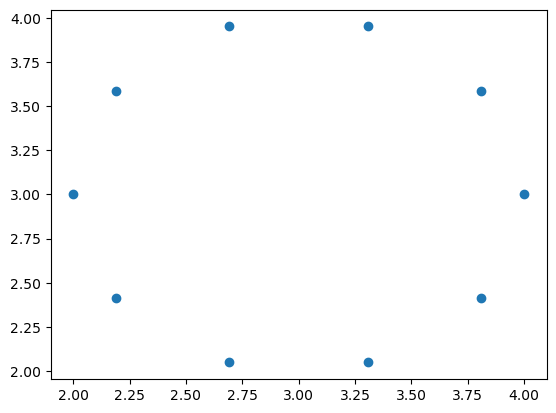

In [22]:
num_waypoints = 10
waypoint_dist = 0.5
waypoints = np.asarray([goal_position + np.array([
    np.cos(2 * np.pi *theta / num_waypoints), 
    np.sin(2 * np.pi * theta / num_waypoints)]) for theta in range(num_waypoints)])

plt.figure()
plt.scatter(waypoints[:, 0], waypoints[:, 1])
plt.show()

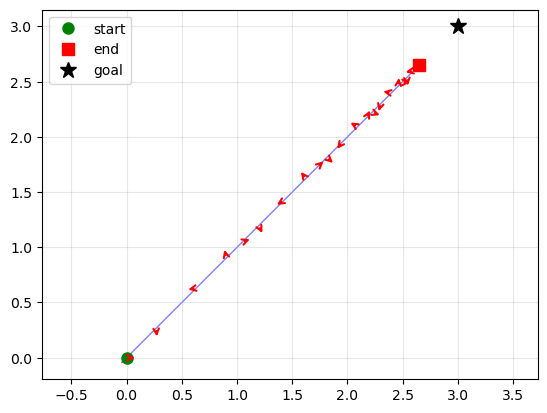

In [98]:
k_r = 1.0
k_a = 20.0
h = 1e-9
dt = 0.01

DIST_THRESH = 0.1 # m
THETA_THRESH = 0.1 # rad

robot_state = np.zeros(3)
path = [robot_state.copy()]

waypoint = goal_position

while np.linalg.norm(waypoint - robot_state[:2]) > 0.5:

    e = np.linalg.norm(waypoint - robot_state[:2])
    b = np.arctan2(robot_state[1] - waypoint[1], robot_state[0] - waypoint[0])

    b = ((b + np.pi) % (2 * np.pi)) - np.pi

    v = k_r * e * np.cos(b - robot_state[2])
    w = k_a * b + 0.5 * k_r * np.sin(2* b) * (b + h * robot_state[2]) / (b + 1e-6)

    robot_state[:2] += dt * v
    robot_state[2] += dt * w
    robot_state[2] = wrap_angle(robot_state[2])

    path.append(robot_state.copy())

path = np.array(path)

plt.figure()
plt.plot(path[:, 0], path[:, 1], 'b-', linewidth=1, alpha=0.5, zorder=1)

step = max(1, len(path) // 20)
for i in range(0, len(path), step):
    x, y = path[i, 0], path[i, 1]
    theta = path[i, 2]
    dx = np.cos(theta) * 0.1
    dy = np.sin(theta) * 0.1
    plt.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.plot(*path[0, :2], 'go', markersize=8, label='start')
plt.plot(*path[-1, :2], 'rs', markersize=8, label='end')
plt.plot(*goal_position, 'k*', markersize=12, label='goal')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

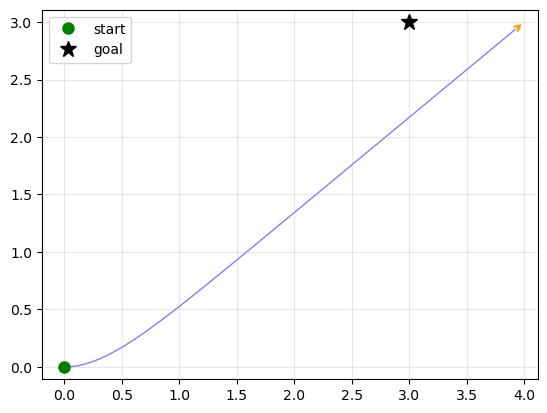

In [ ]:
k_rho = 0.4 # /s
k_alpha = 1.2 # /s
k_beta = 0.0 # /s 
k_theta = 2.0 # /s
v_max = 0.4 # m/s
w_max = 0.8 # rad/s
dt = 0.05

DIST_THRESH = 0.1 # m
THETA_THRESH = 0.1 # rad

robot_state = np.zeros(3)
path = [robot_state.copy()]

waypoint = waypoints[0]

# Phase 1: Move towards waypoint
while np.linalg.norm(waypoint - robot_state[:2]) > DIST_THRESH:

    rho = np.linalg.norm(waypoint - robot_state[:2])
    angle_to_goal = np.arctan2(waypoint[1] - robot_state[1], waypoint[0] - robot_state[0])
    alpha = wrap_angle(angle_to_goal - robot_state[2])
    beta  = wrap_angle(-robot_state[2] - alpha)

    v = k_rho * rho
    w = k_alpha * alpha + k_beta * beta

    v = np.clip(v, -v_max, v_max)
    w = np.clip(w, -w_max, w_max)

    robot_state[0] += dt * v * np.cos(robot_state[2])
    robot_state[1] += dt * v * np.sin(robot_state[2])
    robot_state[2] = wrap_angle(robot_state[2] + dt * w)

    path.append(robot_state.copy())

path = np.array(path)

path_orient = [robot_state.copy()]

# Phase 2: Rotate towards goal
theta_goal = np.arctan2(waypoint[1] - robot_state[1], waypoint[0] - robot_state[0])
while abs(wrap_angle(theta_goal - robot_state[2])) > THETA_THRESH:

    theta = wrap_angle(theta_goal - robot_state[2])
    w = k_theta * theta
    w = np.clip(w, -w_max, w_max)
    robot_state[2] = wrap_angle(robot_state[2] + dt * w)

    path_orient.append(robot_state.copy())

    theta_goal = np.arctan2(waypoint[1] - robot_state[1], waypoint[0] - robot_state[0])

path_orient = np.array(path_orient)

plt.figure()
plt.plot(path[:, 0], path[:, 1], 'b-', linewidth=1, alpha=0.5, zorder=1)

step = max(1, len(path) // 20)
for i in range(0, len(path), step):
    x, y = path[i, 0], path[i, 1]
    theta = path[i, 2]
    dx = np.cos(theta) * 0.1
    dy = np.sin(theta) * 0.1
    plt.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    
for i in range(len(path_orient)):
    x, y = path_orient[i, 0], path_orient[i, 1]
    theta = path_orient[i, 2]
    dx = np.cos(theta) * 0.1
    dy = np.sin(theta) * 0.1
    plt.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                 arrowprops=dict(arrowstyle='->', color='orange', lw=1.5))

plt.plot(*path[0, :2], 'go', markersize=8, label='start')
# plt.plot(*path[-1, :2], 'rs', markersize=8, label='end')
plt.plot(*goal_position, 'k*', markersize=12, label='goal')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [82]:
waypoint

array([4., 3.])